# Pregenerated map gallery and label scores


The application's central map is one choice of inputs. This notebook builds a gallery of alternatives for each organism and scores how well every categorical label maps onto each. The code is `scripts/build_umap_gallery.py` and `starplast/umap_gallery.py`; this notebook calls them, so what is shown is what ships.

Six groups of maps: all measurements at three neighbourhood sizes, an 'all but one family' map per family, one map per evidence family, one per individual experiment block, and the curated pairs and triples of families.

Every map is built from measurements only: label columns are removed from the table before embedding, and the build refuses a map whose matrix contains one.

**Maximising structure.** Every map except the three fixed reference maps is searched over `MAP_GRID` ({'n_neighbors': (10, 25, 60), 'min_dist': (0.0, 0.25)}) x `GALLERY_CLUSTER_GRID` ({'min_cluster_size': (15, 25, 40), 'min_samples': (5, 10)}) and the combination with the best LABEL-FREE structure score ships. The score is `umap_gallery.structure`: the geometric mean of `search.map_quality`'s score (share of genes clustered x evenness of the cluster sizes, zero if the clustering is degenerate) and the mean silhouette of the clustered points rescaled to 0..1. Either alone is gameable -- an even partition of an unseparated cloud scores well on the first, two crisp clusters holding 5% of the proteome on the second -- so a map has to be good at both. No label is read by the search, which is what lets the labels be scored honestly afterwards.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '/media/carruthers/mnt3/claude/repo/starplast'); sys.path.insert(0, '/media/carruthers/mnt3/claude/repo/starplast/scripts')
import build_umap_gallery as B
from starplast import umap_gallery as G
import pandas as pd
_ = pd.set_option('display.width', 220)

## 1. The recipes

A family map needs at least 4 source columns, a single-experiment map at least 3, and every subset map at least 400 genes. A gene is placed when it is measured in at least `min_coverage` of the recipe's columns; the thresholds (0.5, 0.3, 0.15) are tried in order and the strictest that still places enough genes wins, so a dense family is built over well-measured genes and a sparse one is still buildable. The 'all' maps place every gene, as the application does.

In [2]:
rows = []
for code in ['Tg', 'Pf']:
    ctx = B.context(code)
    for r in G.recipes(ctx):
        rows.append({'organism': code, 'group': r['group'], 'map': r['id'],
                     'blocks': len(r['blocks']), 'columns': len(r['columns']),
                     'coverage': r.get('min_coverage', 0.0),
                     'genes': len(G.genes_for(ctx, r)), 'tuned': r['tune']})
recipes = pd.DataFrame(rows)
print(recipes.groupby(['organism', 'group']).size().to_string())
print(recipes.to_string())

organism  group              
Pf        All but one kind       10
          All measurements        3
          Evidence families      10
          Pairs of families      17
          Single experiments     15
          Triples of families     6
Tg        All but one kind        9
          All measurements        3
          Evidence families       9
          Pairs of families      16
          Single experiments     35
          Triples of families     6
    organism                group                                                                    map  blocks  columns  coverage  genes  tuned
0         Tg     All measurements                                                               all_nn10     106      399       0.0   8140  False
1         Tg     All measurements                                                               all_nn25     106      399       0.0   8140  False
2         Tg     All measurements                                                               all_

## 2. Build every map

3D UMAP (umap-learn on the CPU, seed 42, robust scaling, median imputation, each block scaled to equal total variance), then HDBSCAN with 'leaf' selection.

Why 'leaf' and not the Clusters tab's opening setting (25/25, 'eom'): on these maps excess-of-mass returns one to a few clusters holding almost every gene, so every label scores at chance. The comparison cell below measures both on the shipped maps.

The build is checkpointed one map at a time into `results/umap_gallery_checkpoint`, so a run stopped by the memory guard resumes where it left off.

In [3]:
built = B.build(['Tg', 'Pf'], workers=6)
maps = B.maps_table(built)
print(maps.groupby('organism')[['genes', 'clusters', 'structure']].describe().round(3).to_string())
print(maps.to_string())

139 maps over Tg, Pf on 6 worker(s); 0 already built, 139 to build
  [1/139] Tg all_nn10: 8,140 genes, 319 features, 72 clusters, 51% unclustered, structure 0.837 (31.7 s)
  [2/139] Tg all_nn25: 8,140 genes, 319 features, 60 clusters, 55% unclustered, structure 0.808 (34.2 s)
  [3/139] Tg all_nn60: 8,140 genes, 319 features, 60 clusters, 53% unclustered, structure 0.800 (37.8 s)
  [4/139] Tg all_but_localization: 8,140 genes, 305 features, 112 clusters, 50% unclustered, structure 0.893 (83.6 s)
  [5/139] Tg all_but_ptm: 8,140 genes, 307 features, 51 clusters, 43% unclustered, structure 0.885 (87.0 s)
  [6/139] Tg all_but_fitness: 8,140 genes, 275 features, 63 clusters, 49% unclustered, structure 0.892 (80.9 s)
  [7/139] Tg all_but_protein_abundance: 8,140 genes, 307 features, 110 clusters, 48% unclustered, structure 0.886 (64.3 s)
  [8/139] Tg all_but_regulation: 8,140 genes, 312 features, 48 clusters, 48% unclustered, structure 0.893 (65.0 s)
  [9/139] Tg all_but_relation: 8,140 genes

### What the structure search was worth

`gain_on_sample` is the best UMAP setting against the neighbourhood the gallery used to fix for every map (n_neighbors 25, min_dist 0.25), measured at the sample stage where all of them were scored on the same genes. `cluster_spread` is the range the clustering grid covered on the winning embedding. `chose_old_default` is how often the search came back to the setting that used to be hard-coded -- if that were always true, the grid would be hours wasted.

In [4]:
gain = B.search_gain(built)
print(gain.groupby('organism')[['shipped', 'sample_best', 'sample_at_old_default', 'gain_on_sample', 'spread_full']].describe().round(3).to_string())
print(gain.groupby('organism')['chose_old_default'].mean().round(3).to_string())
print(gain.sort_values('gain_on_sample', ascending=False).head(15).to_string())

         shipped                                                  sample_best                                                  sample_at_old_default                                                  gain_on_sample                                                  spread_full                                               
           count   mean    std    min    25%    50%    75%    max       count   mean    std    min    25%    50%    75%    max                 count   mean    std    min    25%    50%    75%    max          count   mean    std    min    25%    50%    75%    max       count   mean    std  min    25%    50%    75%    max
organism                                                                                                                                                                                                                                                                                                                        
Pf          58.0  0.899  0.023  0.872

In [5]:
searched = B.search_table(built)
print(len(searched), 'settings tried in total')
print(searched.groupby(['organism', 'stage']).size().to_string())
print(searched.groupby(['n_neighbors', 'min_dist'])['structure'].mean().round(3).to_string())
print(searched.groupby(['min_cluster_size', 'min_samples'])['structure'].mean().round(3).to_string())

1064 settings tried in total
organism  stage 
Pf        full      116
          sample    348
Tg        full      150
          sample    450
n_neighbors  min_dist
10           0.00        0.890
             0.25        0.864
25           0.00        0.885
             0.25        0.859
60           0.00        0.882
             0.25        0.857
min_cluster_size  min_samples
15                5              0.858
                  10             0.889
25                5              0.853
                  10             0.876
40                5              0.854
                  10             0.871


### The best and the worst maps by structure

In [6]:
for code, t in maps.groupby('organism'):
    print(code, 'BEST'); print(t.head(8)[['map', 'group', 'genes', 'clusters', 'clustered', 'evenness', 'separation', 'structure']].to_string(index=False))
    print(code, 'WORST'); print(t.tail(8)[['map', 'group', 'genes', 'clusters', 'clustered', 'evenness', 'separation', 'structure']].to_string(index=False))

Pf BEST
                                            map              group  genes  clusters  clustered  evenness  separation  structure
block_pf_field_variation_and_resistance_markers Single experiments   5225       155     0.9805    0.9886      0.9751     0.9818
              block_pf_fold_confidence_disorder Single experiments   5098       194     0.9437    0.9912      0.9372     0.9639
                   block_pf_protein_stage_share Single experiments   2706        83     0.9313    0.9771      0.9491     0.9630
                            family_localization  Evidence families   5318       162     0.9615    0.9831      0.9225     0.9523
                       block_pf_sequence_basics Single experiments   5318       196     0.9462    0.9889      0.8994     0.9431
                               family_chemistry  Evidence families    734        13     0.9401    0.9407      0.9167     0.9287
                    combo_relation_localization  Pairs of families   3556       109     0.8777  

In [7]:
compare = B.compare_clusterings(built)
print(compare.groupby(['organism', 'setting'])[['clusters', 'unclustered', 'category_skill']].median().to_string())

                                clusters  unclustered  category_skill
organism setting                                                     
Pf       gallery                    81.0       0.3590           0.062
         tab opening 25/25 eom      19.0       0.0390           0.036
Tg       gallery                   102.5       0.4130           0.044
         tab opening 25/25 eom      17.0       0.0305           0.020


### The 24 best-structured Tg maps, first two components, colored by cluster

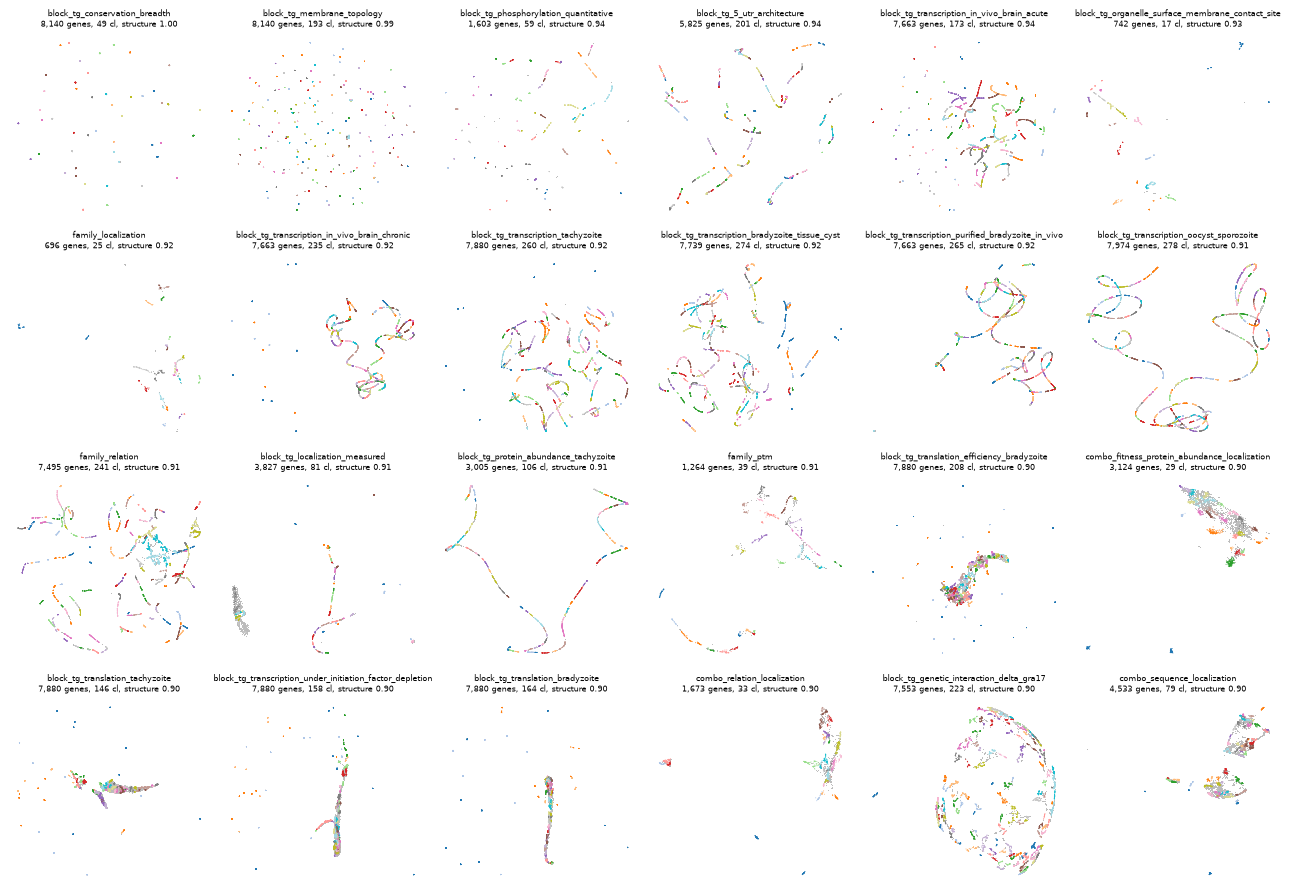

In [8]:
B.figure(built, 'Tg')

### The 24 best-structured Pf maps, first two components, colored by cluster

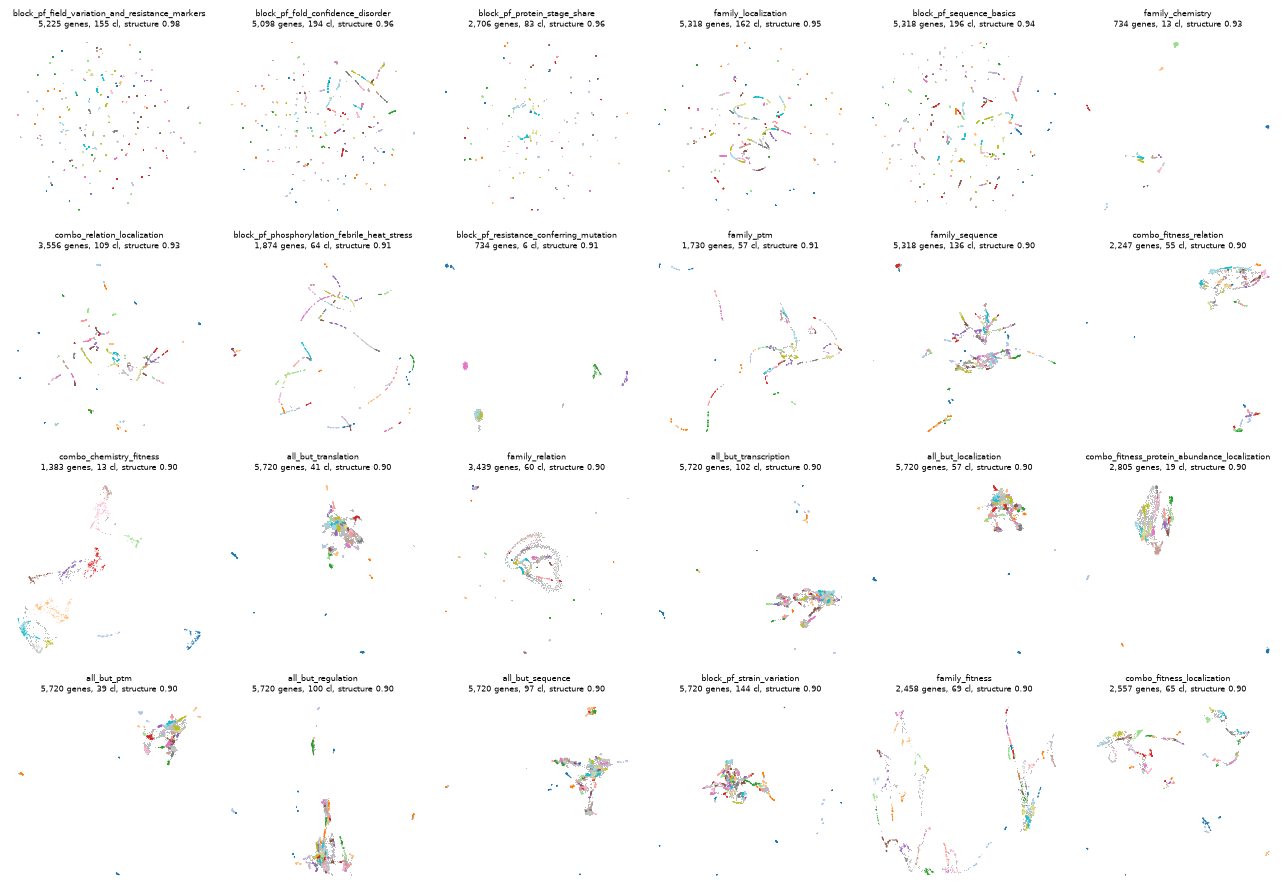

In [9]:
B.figure(built, 'Pf')

## 3. Score every label on every map

Categories → clusters: size-weighted mean over categories of the F1 of each category's best cluster (unclustered genes count as missed). Best category: the category whose F1 of the Wilson 95% lower bounds of precision and recall beats its own shuffled-label chance by the most. Chance: 5 shuffles of the label over the same genes. Circular: the map was built from a column in the label's leakage closure.

In [10]:
scores = B.score(built)
print(len(scores), 'label x map rows')
scores.groupby('organism').size()

scoring Tg all_nn10
scoring Tg all_nn25
scoring Tg all_nn60
scoring Tg all_but_localization
scoring Tg all_but_ptm
scoring Tg all_but_fitness
scoring Tg all_but_protein_abundance
scoring Tg all_but_regulation
scoring Tg all_but_relation
scoring Tg all_but_sequence
scoring Tg all_but_transcription
scoring Tg all_but_translation
scoring Tg family_fitness
scoring Tg family_localization
scoring Tg family_protein_abundance
scoring Tg family_ptm
scoring Tg family_regulation
scoring Tg family_relation
scoring Tg family_sequence
scoring Tg family_transcription
scoring Tg family_translation
scoring Tg block_tg_5_utr_architecture
scoring Tg block_tg_codon_usage_translation_efficiency
scoring Tg block_tg_conservation_breadth
scoring Tg block_tg_fitness_carbon_source_withdrawal
scoring Tg block_tg_fitness_parasite_density
scoring Tg block_tg_fitness_serum_restriction
scoring Tg block_tg_genetic_interaction_delta_gra17
scoring Tg block_tg_local_af3_fold_confidence_and_geometry
scoring Tg block_tg_l

organism
Pf    1098
Tg    1404

### Tg: its first calibration target on every map

Best first by 'categories → clusters' skill. A map marked circular was built from a column that restates the label.

In [11]:
label = B.headline_label('Tg')
print(label)
print(G.describe(scores[scores.organism == 'Tg'], label))

compartment
family_localization      categories→clusters 0.319 (skill +0.221)  best dense granules n=41 0.617 (skill +0.596)  [circular]
combo_relation_localization categories→clusters 0.217 (skill +0.142)  best dense granules n=94 0.470 (skill +0.448)  [circular]
block_tg_organelle_surface_membrane_contact_site categories→clusters 0.241 (skill +0.120)  best mitochondrion - membranes n=35 0.336 (skill +0.293)
all_but_ptm              categories→clusters 0.175 (skill +0.117)  best PM - peripheral 1 n=49 0.493 (skill +0.482)  [circular]
all_but_fitness          categories→clusters 0.166 (skill +0.113)  best 60S ribosome n=40 0.563 (skill +0.553)  [circular]
all_but_regulation       categories→clusters 0.168 (skill +0.112)  best 60S ribosome n=40 0.537 (skill +0.528)  [circular]
combo_fitness_protein_abundance_localization categories→clusters 0.179 (skill +0.111)  best 60S ribosome n=40 0.416 (skill +0.397)  [circular]
all_but_relation         categories→clusters 0.162 (skill +0.108)  bes

### Pf: its first calibration target on every map

Best first by 'categories → clusters' skill. A map marked circular was built from a column that restates the label.

In [12]:
label = B.headline_label('Pf')
print(label)
print(G.describe(scores[scores.organism == 'Pf'], label))

lopit_pf_location
combo_protein_abundance_localization categories→clusters 0.292 (skill +0.207)  best ribosomes n=64 0.481 (skill +0.457)  [circular]
combo_fitness_protein_abundance_localization categories→clusters 0.238 (skill +0.153)  best ribosomes n=64 0.411 (skill +0.387)  [circular]
all_but_relation         categories→clusters 0.223 (skill +0.146)  best ribosomes n=65 0.604 (skill +0.586)  [circular]
combo_relation_protein_abundance categories→clusters 0.225 (skill +0.144)  best ribosomes n=64 0.542 (skill +0.524)  [circular]
all_but_translation      categories→clusters 0.209 (skill +0.130)  best ribosomes n=65 0.564 (skill +0.545)  [circular]
all_but_ptm              categories→clusters 0.202 (skill +0.128)  best ribosomes n=65 0.599 (skill +0.583)  [circular]
combo_transcription_protein_abundance categories→clusters 0.206 (skill +0.125)  best ribosomes n=65 0.583 (skill +0.568)  [circular]
family_protein_abundance categories→clusters 0.203 (skill +0.117)  best ribosomes n=64 0.

## 4. The size-aware bound on real data

Across every label and map: how often the best category by raw F1 is a small category, and how often it still is once the Wilson bound and the chance correction decide.

In [13]:
small = scores[scores.best_n < 30]
print(f'best categories under 30 genes: {len(small)} of {len(scores)}')
print(small[['organism', 'label', 'map', 'best_category', 'best_n', 'best_precision', 'best_recall', 'best_f1_lower', 'best_skill']].round(3).head(15).to_string())

best categories under 30 genes: 364 of 2502
    organism                 label                        map best_category  best_n  best_precision  best_recall  best_f1_lower  best_skill
8         Tg    compartment_source                   all_nn10    orthoLOPIT      28           0.091        0.071          0.022       0.006
44        Tg    compartment_source                   all_nn60    orthoLOPIT      28           0.100        0.107          0.036       0.018
51        Tg  screen_scorers_agree                   all_nn60          True      27           0.667        0.074          0.037       0.004
62        Tg    compartment_source       all_but_localization    orthoLOPIT      28           0.049        0.107          0.023       0.007
69        Tg  screen_scorers_agree       all_but_localization          True      27           0.500        0.185          0.122       0.078
80        Tg    compartment_source                all_but_ptm    orthoLOPIT      28           0.062        0.107    

## 5. Which map wins for each label

The point of a gallery this size: for every label, the map its categories fall into clusters on best, and whether that map is one a user would have thought of. A map marked circular was built from a column in the label's leakage closure.

In [14]:
best = (scores[scores.circular.astype(str) != 'True']
        .sort_values('category_skill', ascending=False)
        .groupby(['organism', 'label']).head(1))
print(best[['organism', 'label', 'map', 'category_f1', 'category_skill', 'genes_scored']].round(3).to_string(index=False))

organism                        label                                              map  category_f1  category_skill  genes_scored
      Pf                   chromosome                                  family_relation        0.220           0.174          3439
      Tg              cellcycle_phase                              family_localization        0.356           0.141           106
      Pf       stage_enriched_derived                                 family_chemistry        0.469           0.136            33
      Tg             ortholopit_label block_tg_organelle_surface_membrane_contact_site        0.323           0.136           178
      Tg                lopit_unified block_tg_organelle_surface_membrane_contact_site        0.261           0.135           698
      Tg             compartment_best block_tg_organelle_surface_membrane_contact_site        0.261           0.130           698
      Tg                   lopit_mcmc block_tg_organelle_surface_membrane_contact_site    

## 6. Write the shipped files

In [15]:
paths = B.write(built, scores)
import os
print({k: round(os.path.getsize(p) / 1e6, 2) for k, p in paths.items()}, 'MB')

coords    starplast/data/umap_gallery.npz  10.46 MB
manifest  starplast/data/umap_gallery.json  1.24 MB
scores    starplast/data/umap_gallery_scores.tsv  0.43 MB
{'coords': 10.46, 'manifest': 1.24, 'scores': 0.43} MB
